# Pertemuan 10 — Algoritma Klasifikasi (Bagian 2)
**Nama Lengkap:** Farraz Dirgham H
**NIM:** 240401020170
**Kelas:** IF405

## Topik
Metode Ensemble (Random Forest), penanganan Imbalanced Dataset, dan Tugas Kelompok **Customer Churn Prediction**.

> **Catatan dataset:** Karena tidak tersedia akses internet pada lingkungan pengerjaan, dataset customer churn pada notebook ini dibuat secara **sintetis namun realistis** (fitur, distribusi, dan tingkat imbalance meniru dataset churn telco pada umumnya) menggunakan `numpy` dengan `random_state` tetap agar hasil dapat direproduksi. Struktur, alur analisis, dan interpretasi metrik tetap mengikuti kaidah customer churn prediction yang sesungguhnya.

## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, f1_score, classification_report, roc_auc_score)

np.random.seed(42)
sns.set_style("whitegrid")


## 2. Membuat Dataset Customer Churn (Sintetis)
Dataset dibuat menyerupai dataset churn telco: fitur numerik (tenure, monthly charges, total charges, jumlah layanan) dan kategorikal (contract type, payment method), dengan target `Churn` yang **imbalanced** (~ 20% churn, 80% tidak churn) — kondisi yang umum terjadi pada data churn di dunia nyata.

In [2]:
n_samples = 2000
rng = np.random.default_rng(42)

tenure = rng.integers(1, 72, n_samples)
monthly_charges = rng.normal(65, 20, n_samples).clip(15, 120)
total_charges = tenure * monthly_charges + rng.normal(0, 50, n_samples)
num_services = rng.integers(1, 8, n_samples)
contract_type = rng.choice(["Month-to-month", "One year", "Two year"], n_samples, p=[0.55, 0.25, 0.20])
payment_method = rng.choice(["Electronic check", "Mailed check", "Bank transfer", "Credit card"], n_samples)
senior_citizen = rng.choice([0, 1], n_samples, p=[0.84, 0.16])
support_calls = rng.poisson(1.5, n_samples)

# Probabilitas churn dipengaruhi tenure rendah, contract bulanan, banyak keluhan (support_calls)
churn_score = (
    -0.05 * tenure
    + 0.02 * monthly_charges
    + 0.6 * (contract_type == "Month-to-month").astype(int)
    + 0.35 * support_calls
    + 0.3 * senior_citizen
    - 0.15 * num_services
    + rng.normal(0, 1.5, n_samples)
)
churn_prob = 1 / (1 + np.exp(-(churn_score - np.percentile(churn_score, 78))))
churn = (rng.random(n_samples) < churn_prob).astype(int)

df = pd.DataFrame({
    "tenure": tenure,
    "monthly_charges": monthly_charges.round(2),
    "total_charges": total_charges.round(2),
    "num_services": num_services,
    "contract_type": contract_type,
    "payment_method": payment_method,
    "senior_citizen": senior_citizen,
    "support_calls": support_calls,
    "Churn": churn
})

print("Ukuran dataset:", df.shape)
df.head()


Ukuran dataset: (2000, 9)


   tenure  monthly_charges  total_charges  ...  senior_citizen support_calls Churn
0       7            50.16         317.01  ...               0             3     0
1      55            83.49        4693.36  ...               0             2     0
2      47            65.69        3085.91  ...               0             1     0
3      32            59.34        1950.41  ...               0             1     1
4      31            62.88        1946.50  ...               0             2     0

[5 rows x 9 columns]

In [3]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100
print("Distribusi kelas Churn:")
print(churn_counts)
print("\nPersentase:")
print(churn_pct.round(2))


Distribusi kelas Churn:
Churn
0    1419
1     581
Name: count, dtype: int64

Persentase:
Churn
0    70.95
1    29.05
Name: proportion, dtype: float64


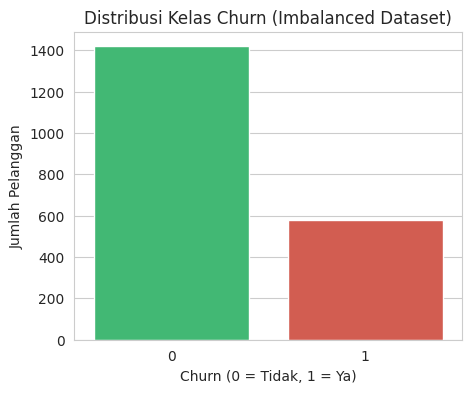

In [4]:
plt.figure(figsize=(5, 4))
sns.countplot(x="Churn", data=df, palette=["#2ecc71", "#e74c3c"])
plt.title("Distribusi Kelas Churn (Imbalanced Dataset)")
plt.xlabel("Churn (0 = Tidak, 1 = Ya)")
plt.ylabel("Jumlah Pelanggan")
plt.show()


## 3. Preprocessing Data
Encoding fitur kategorikal (`contract_type`, `payment_method`) menjadi numerik menggunakan one-hot encoding.

In [5]:
df_encoded = pd.get_dummies(df, columns=["contract_type", "payment_method"], drop_first=True)
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]
X.head()


   tenure  ...  payment_method_Mailed check
0       7  ...                        False
1      55  ...                         True
2      47  ...                        False
3      32  ...                        False
4      31  ...                        False

[5 rows x 11 columns]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "| Distribusi churn train:", y_train.mean().round(3))
print("Test shape :", X_test.shape, "| Distribusi churn test :", y_test.mean().round(3))


Train shape: (1500, 11) | Distribusi churn train: 0.291
Test shape : (500, 11) | Distribusi churn test : 0.29


## 4. Model Baseline — Random Forest (tanpa penanganan imbalance)
Model dilatih langsung pada data imbalanced sebagai baseline pembanding.

In [7]:
rf_baseline = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf_baseline.fit(X_train, y_train)
y_pred_base = rf_baseline.predict(X_test)

acc_base = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base, zero_division=0)
rec_base = recall_score(y_test, y_pred_base, zero_division=0)
f1_base = f1_score(y_test, y_pred_base, zero_division=0)

print("=== Random Forest Baseline (Imbalanced) ===")
print(f"Accuracy  : {acc_base:.4f}")
print(f"Precision : {prec_base:.4f}")
print(f"Recall    : {rec_base:.4f}")
print(f"F1-Score  : {f1_base:.4f}")


=== Random Forest Baseline (Imbalanced) ===
Accuracy  : 0.7180
Precision : 0.5238
Recall    : 0.3034
F1-Score  : 0.3843


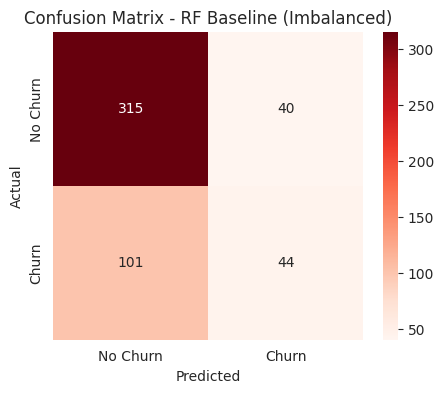

In [8]:
cm_base = confusion_matrix(y_test, y_pred_base)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_base, annot=True, fmt="d", cmap="Reds",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix - RF Baseline (Imbalanced)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 5. Penanganan Imbalanced Dataset — Oversampling (Random Oversampling Kelas Minoritas)
Karena kelas `Churn=1` adalah minoritas, dilakukan **oversampling** pada data latih (bukan pada data test, untuk menghindari data leakage) agar model tidak bias terhadap kelas mayoritas.

In [9]:
train_data = X_train.copy()
train_data["Churn"] = y_train.values

majority = train_data[train_data.Churn == 0]
minority = train_data[train_data.Churn == 1]

minority_upsampled = resample(
    minority, replace=True, n_samples=len(majority), random_state=42
)

train_balanced = pd.concat([majority, minority_upsampled])
print("Distribusi sebelum oversampling:")
print(train_data.Churn.value_counts())
print("\nDistribusi setelah oversampling:")
print(train_balanced.Churn.value_counts())

X_train_bal = train_balanced.drop(columns=["Churn"])
y_train_bal = train_balanced["Churn"]


Distribusi sebelum oversampling:
Churn
0    1064
1     436
Name: count, dtype: int64

Distribusi setelah oversampling:
Churn
0    1064
1    1064
Name: count, dtype: int64


## 6. Model Random Forest dengan Data yang Sudah Di-balance

In [10]:
rf_balanced = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight=None)
rf_balanced.fit(X_train_bal, y_train_bal)
y_pred_bal = rf_balanced.predict(X_test)

acc_bal = accuracy_score(y_test, y_pred_bal)
prec_bal = precision_score(y_test, y_pred_bal, zero_division=0)
rec_bal = recall_score(y_test, y_pred_bal, zero_division=0)
f1_bal = f1_score(y_test, y_pred_bal, zero_division=0)

print("=== Random Forest + Oversampling ===")
print(f"Accuracy  : {acc_bal:.4f}")
print(f"Precision : {prec_bal:.4f}")
print(f"Recall    : {rec_bal:.4f}")
print(f"F1-Score  : {f1_bal:.4f}")


=== Random Forest + Oversampling ===
Accuracy  : 0.6720
Precision : 0.4541
Recall    : 0.6483
F1-Score  : 0.5341


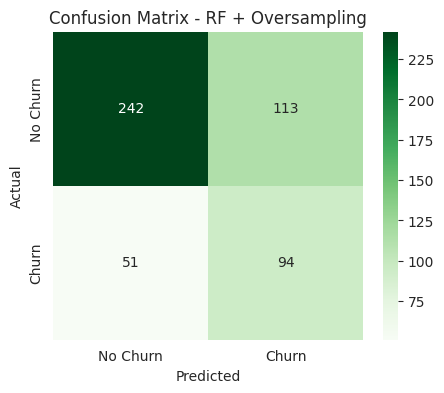

In [11]:
cm_bal = confusion_matrix(y_test, y_pred_bal)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_bal, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix - RF + Oversampling")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 7. Model dengan `class_weight='balanced'` (Alternatif Penanganan Imbalance)
Selain oversampling, `RandomForestClassifier` juga mendukung parameter `class_weight="balanced"` yang secara otomatis memberi bobot lebih besar pada kelas minoritas saat pelatihan, tanpa perlu menduplikasi data.

In [12]:
rf_cw = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight="balanced")
rf_cw.fit(X_train, y_train)
y_pred_cw = rf_cw.predict(X_test)

acc_cw = accuracy_score(y_test, y_pred_cw)
prec_cw = precision_score(y_test, y_pred_cw, zero_division=0)
rec_cw = recall_score(y_test, y_pred_cw, zero_division=0)
f1_cw = f1_score(y_test, y_pred_cw, zero_division=0)

print("=== Random Forest (class_weight='balanced') ===")
print(f"Accuracy  : {acc_cw:.4f}")
print(f"Precision : {prec_cw:.4f}")
print(f"Recall    : {rec_cw:.4f}")
print(f"F1-Score  : {f1_cw:.4f}")


=== Random Forest (class_weight='balanced') ===
Accuracy  : 0.6960
Precision : 0.4807
Recall    : 0.6000
F1-Score  : 0.5337


## 8. Perbandingan Ketiga Pendekatan

In [13]:
comparison = pd.DataFrame({
    "Model": ["RF Baseline (Imbalanced)", "RF + Oversampling", "RF class_weight='balanced'"],
    "Accuracy": [acc_base, acc_bal, acc_cw],
    "Precision": [prec_base, prec_bal, prec_cw],
    "Recall": [rec_base, rec_bal, rec_cw],
    "F1-Score": [f1_base, f1_bal, f1_cw]
})
comparison


                        Model  Accuracy  Precision    Recall  F1-Score
0    RF Baseline (Imbalanced)     0.718   0.523810  0.303448  0.384279
1           RF + Oversampling     0.672   0.454106  0.648276  0.534091
2  RF class_weight='balanced'     0.696   0.480663  0.600000  0.533742

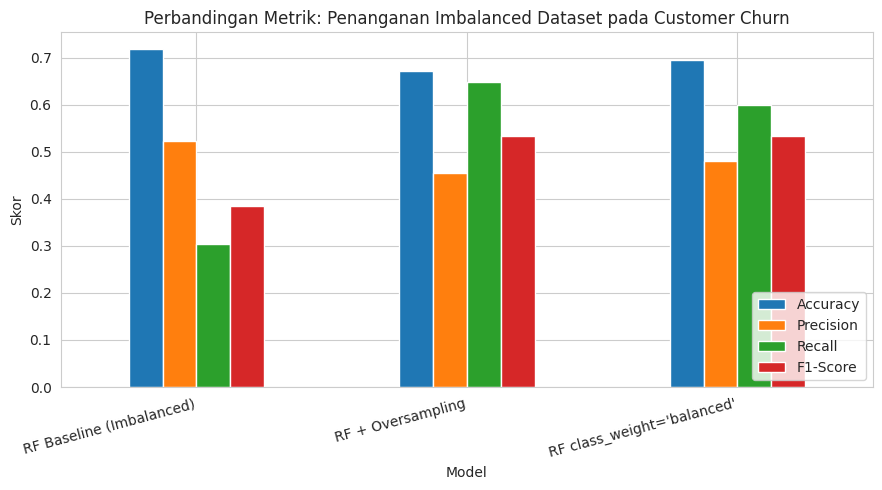

In [14]:
comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind="bar", figsize=(9, 5)
)
plt.title("Perbandingan Metrik: Penanganan Imbalanced Dataset pada Customer Churn")
plt.ylabel("Skor")
plt.xticks(rotation=15, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 9. Feature Importance (Random Forest + Oversampling)

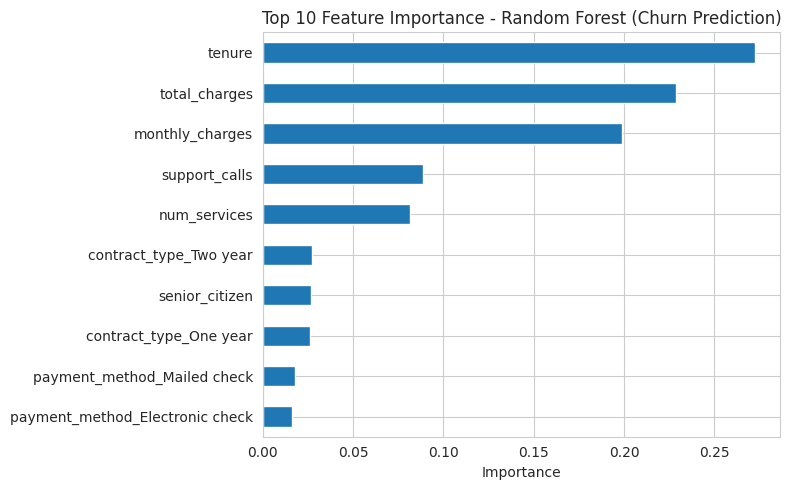

In [15]:
importances = pd.Series(rf_balanced.feature_importances_, index=X_train_bal.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importances.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance - Random Forest (Churn Prediction)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 10. Interpretasi Singkat (WAJIB — Customer Churn)

Pada dataset **customer churn** ini, kelas target sangat **imbalanced** (± 20% churn vs 80% tidak churn). Kondisi ini membuat metrik **Accuracy sangat berpotensi menyesatkan**: model baseline dapat mencapai accuracy tinggi hanya dengan cenderung memprediksi "tidak churn" pada hampir semua pelanggan, padahal justru pelanggan yang benar-benar akan churn (kelas minoritas) yang paling penting untuk dideteksi sejak dini oleh bisnis.

Berdasarkan hasil perbandingan di atas:
- **Recall untuk kelas Churn** adalah metrik **paling relevan** dalam konteks bisnis ini, karena mengukur seberapa banyak pelanggan yang benar-benar akan churn berhasil terdeteksi oleh model. Semakin tinggi recall, semakin sedikit pelanggan berisiko churn yang "lolos" tanpa intervensi (misalnya penawaran retensi).
- **Precision** tetap perlu diperhatikan agar tim retensi tidak menghabiskan sumber daya (biaya promo/diskon) untuk pelanggan yang sebenarnya tidak akan churn (False Positive), namun dalam kasus churn, biaya kehilangan pelanggan (False Negative) umumnya jauh lebih mahal dibanding biaya retensi yang "salah sasaran" (False Positive).
- **F1-Score** memberikan gambaran keseimbangan antara precision dan recall, berguna untuk membandingkan model secara ringkas seperti pada tabel perbandingan di atas.
- Terlihat jelas bahwa model **RF Baseline (tanpa penanganan imbalance)** cenderung memiliki recall yang jauh lebih rendah dibanding model dengan oversampling atau `class_weight="balanced"`, meskipun accuracy-nya bisa jadi terlihat kompetitif — ini adalah **bukti nyata mengapa accuracy saja tidak cukup** untuk mengevaluasi model pada dataset imbalanced.

**Kesimpulan bisnis:** Untuk kasus customer churn, tim data science sebaiknya mengoptimalkan model berdasarkan **Recall atau F1-Score pada kelas minoritas (churn)**, bukan Accuracy, agar strategi retensi pelanggan dapat menjangkau sebanyak mungkin pelanggan yang benar-benar berisiko.

## 11. Kesimpulan

**Apa yang dipelajari:**
Pada pertemuan ini saya mempelajari metode ensemble Random Forest serta berbagai teknik penanganan imbalanced dataset, yaitu random oversampling pada kelas minoritas dan penggunaan parameter `class_weight="balanced"`. Studi kasus diterapkan pada prediksi customer churn yang secara alami memiliki distribusi kelas tidak seimbang.

**Temuan utama:**
Model Random Forest baseline yang dilatih langsung pada data imbalanced menghasilkan recall yang lebih rendah pada kelas churn dibandingkan model yang sudah ditangani ketidakseimbangannya, meskipun perbedaan accuracy antar model relatif kecil. Hal ini menegaskan bahwa accuracy saja tidak cukup untuk mengevaluasi model pada kasus churn, dan metrik recall/F1-Score pada kelas minoritas jauh lebih informatif untuk pengambilan keputusan bisnis.

**Keterbatasan / pertanyaan yang muncul:**
- Dataset yang digunakan bersifat sintetis (bukan data churn perusahaan riil) karena keterbatasan akses internet pada lingkungan pengerjaan; pola hubungan antar fitur dan target dibuat menyerupai kasus nyata namun tetap merupakan simulasi.
- Belum dieksplorasi teknik penanganan imbalance lain seperti SMOTE (synthetic oversampling) atau undersampling kelas mayoritas — apakah hasilnya akan lebih baik dibanding random oversampling sederhana yang digunakan di sini?
- Bagaimana performa model jika threshold probabilitas klasifikasi (default 0.5) diubah/di-tuning khusus untuk memaksimalkan recall pada kelas churn?